# **Install Libraries**

In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn

# **Import Libraries**


In [2]:
import pandas as pd
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# **Load Dataset**

In [3]:
df = pd.read_csv("bbc-text.csv")

df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


# **Explore Dataset**

In [4]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows")
display(df.head())

print("\nCategories")
print(df["category"].value_counts())

Dataset Shape: (2225, 2)

First 5 Rows


,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...



Categories
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


# **Preprocessing**

In [5]:
stop_words = set(stopwords.words("english"))

def preprocess(text):

    text = text.lower()

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(preprocess)

df.head()

,category,text,clean_text
0,tech,tv future in the hands of viewers with home th...,tv future hands viewers home theatre systems p...
1,business,worldcom boss left books alone former worldc...,worldcom boss left books alone former worldcom...
2,sport,tigers wary of farrell gamble leicester say ...,tigers wary farrell gamble leicester say rushe...
3,sport,yeading face newcastle in fa cup premiership s...,yeading face newcastle fa cup premiership side...
4,entertainment,ocean s twelve raids box office ocean s twelve...,ocean twelve raids box office ocean twelve cri...


# **Train/Test Split**

In [6]:
X = df["clean_text"]

y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 1780
Testing Samples: 445


# **Build Model**

In [7]:
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


Prediction

In [8]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9798


# **Classification Report**

In [9]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.96      0.97      0.97       102
entertainment       0.97      0.99      0.98        77
     politics       0.98      0.98      0.98        84
        sport       1.00      1.00      1.00       102
         tech       0.99      0.96      0.97        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



# **Confusion Matrix**

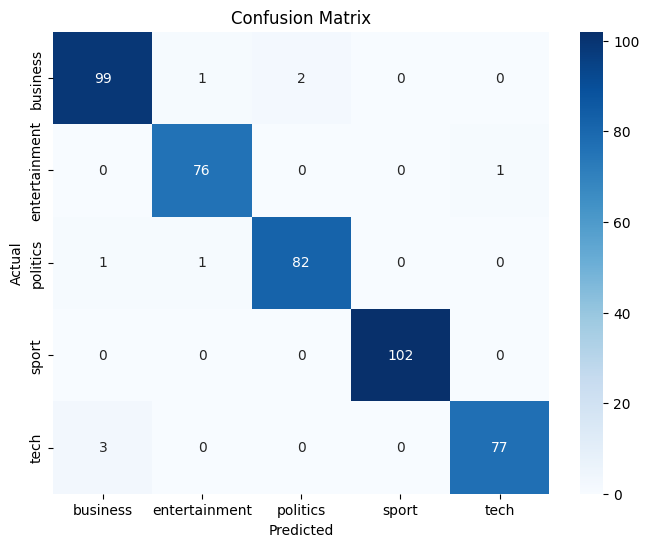

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# **Test Your Own Text**

In [11]:
news = input("Enter a news article or headline:\n")

prediction = model.predict([news])[0]

print("\nPredicted Category:", prediction)

Enter a news article or headline:
Manchester United secured a 3-1 victory after scoring two goals in the second half to reach the tournament final.

Predicted Category: sport
